# Análise Exploratória de Dados — Datathon FIAP (Passos Mágicos)
Este notebook tem como objetivo explorar padrões nos indicadores educacionais da Associação Passos Mágicos e responder às perguntas de negócio propostas no Datathon, gerando evidências para o storytelling analítico e para a etapa de modelagem preditiva.

## Importação das bibliotecas e configurações




In [ ]:
from IPython.core.display import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

## Carregamento da Base

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/RickPardono/Datathon_FIAP/refs/heads/main/data/processed/base_tratada.csv")

In [ ]:
df.head()

,RA,Fase,Turma,ano,nome,ano_nascimento,idade,genero,ano_ingresso,instituicao_ensino,pedra,inde,num_avaliacoes,fase_ideal,defasagem,ian,iaa,ieg,ips,ida,ipv,mat,por,ing,ipp,pedra_ordem,num_notas_disponiveis,media_notas_disponiveis
0,RA-1,7,A,2022,Aluno-1,2003,19,Feminino,2016,Pública,Quartzo,5.783,4,8,-1,5.0,8.3,4.1,5.6,4.0,7.278,2.7,3.5,6.0,NaN,1.0,3,4.066667
1,RA-1,8,E,2023,Aluno-1,2003,20,Feminino,2016,Privada com bolsa/apadrinhamento,NaN,NaN,0,8,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,RA-1,8,E,2024,Aluno-1,2003,21,Feminino,2021,Privada com bolsa/apadrinhamento,NaN,NaN,0,8,0,10.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,RA-2,7,A,2022,Aluno-2,2005,17,Feminino,2017,Privada,Ametista,7.055,4,7,0,10.0,8.8,5.2,6.3,6.8,6.778,6.3,4.5,9.7,NaN,3.0,3,6.833333
4,RA-2,8,E,2023,Aluno-2,2005,18,Feminino,2017,Privada com bolsa/apadrinhamento,NaN,NaN,0,8,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   RA                       3030 non-null   object 
 1   Fase                     3030 non-null   int64  
 2   Turma                    3030 non-null   object 
 3   ano                      3030 non-null   int64  
 4   nome                     3030 non-null   object 
 5   ano_nascimento           3030 non-null   int64  
 6   idade                    3030 non-null   int64  
 7   genero                   3030 non-null   object 
 8   ano_ingresso             3030 non-null   int64  
 9   instituicao_ensino       3029 non-null   object 
 10  pedra                    2845 non-null   object 
 11  inde                     2845 non-null   float64
 12  num_avaliacoes           3030 non-null   int64  
 13  fase_ideal               3030 non-null   int64  
 14  defasagem               

##  Visão Geral da base

In [ ]:
df.describe()

,Fase,ano,ano_nascimento,idade,ano_ingresso,inde,num_avaliacoes,fase_ideal,defasagem,ian,iaa,ieg,ips,ida,ipv,mat,por,ing,ipp,pedra_ordem,num_notas_disponiveis,media_notas_disponiveis
count,3030.000000,3030.00000,3030.000000,3030.000000,3030.000000,2845.000000,3030.000000,3030.000000,3030.000000,3030.000000,2865.000000,2954.000000,2859.000000,2852.000000,2852.000000,2846.000000,2845.000000,1091.000000,1992.000000,2845.000000,3030.000000,2850.000000
mean,2.557426,2023.09769,2010.454455,12.527063,2021.563696,7.269915,2.955776,3.202310,-0.642904,7.179043,7.918225,7.945696,6.287129,6.375964,7.545476,6.161595,6.430668,6.289413,7.555203,2.766257,2.238284,6.372099
std,2.255364,0.80995,3.314445,3.299273,1.822171,0.991767,1.152326,2.180452,0.866382,2.535266,2.626209,2.152281,1.792491,1.956637,1.084347,2.398341,2.138916,2.732636,0.938990,0.940860,0.735363,1.948264
min,0.000000,2022.00000,1996.000000,7.000000,2016.000000,3.032000,0.000000,0.000000,-5.000000,2.500000,0.000000,0.000000,2.500000,0.000000,2.500000,0.000000,0.000000,0.000000,2.500000,1.000000,0.000000,0.000000
25%,1.000000,2022.00000,2008.000000,10.000000,2021.000000,6.675200,2.000000,2.000000,-1.000000,5.000000,7.900000,7.300000,5.020000,5.100000,6.984000,4.800000,5.200000,4.500000,7.083333,2.000000,2.000000,5.100000
50%,2.000000,2023.00000,2011.000000,12.000000,2022.000000,7.388267,3.000000,3.000000,-1.000000,5.000000,8.751000,8.600000,7.500000,6.666667,7.583000,6.300000,6.700000,6.700000,7.500000,3.000000,2.000000,6.650000
75%,4.000000,2024.00000,2013.000000,15.000000,2023.000000,7.986867,4.000000,4.000000,0.000000,10.000000,9.500000,9.400000,7.510000,7.833333,8.255000,8.000000,8.000000,8.500000,8.125000,3.000000,3.000000,7.850000
max,9.000000,2024.00000,2017.000000,27.000000,2024.000000,9.531325,6.000000,8.000000,3.000000,10.000000,10.002000,10.000000,10.000000,10.000000,10.010000,10.000000,10.000000,10.000000,10.000000,4.000000,3.000000,10.000000


In [ ]:
df.isna().mean().sort_values(ascending=False)

,0
ing,0.639934
ipp,0.342574
inde,0.061056
pedra,0.061056
pedra_ordem,0.061056
por,0.061056
mat,0.060726
media_notas_disponiveis,0.059406
ipv,0.058746
ida,0.058746


## Pergunta 1 — Adequação do nível (IAN)
Nesta seção, analisamos o perfil geral de defasagem dos alunos a partir do indicador IAN, observando sua distribuição e evolução ao longo dos anos. O objetivo é identificar:
- quantos alunos estão em situação adequada, moderadamente defasada ou severamente defasada;
- se houve melhora ou piora na composição dessas classes ao longo do tempo.

In [ ]:
df["ian"].value_counts(normalize=True)

,proportion
ian,
5.0,0.541914
10.0,0.443234
2.5,0.014851


In [ ]:
df["ian"].value_counts()

,count
ian,
5.0,1642
10.0,1343
2.5,45


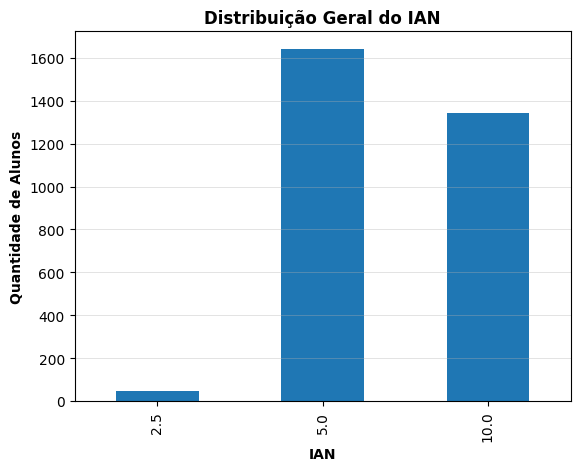

In [ ]:
df["ian"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição Geral do IAN", weight="bold")
plt.xlabel("IAN", weight="bold")
plt.ylabel("Quantidade de Alunos", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.show()

In [ ]:
df.groupby(['ano','ian']).size().unstack()

ian,2.5,5.0,10.0
ano,,,
2022,28,573,259
2023,14,538,462
2024,3,531,622


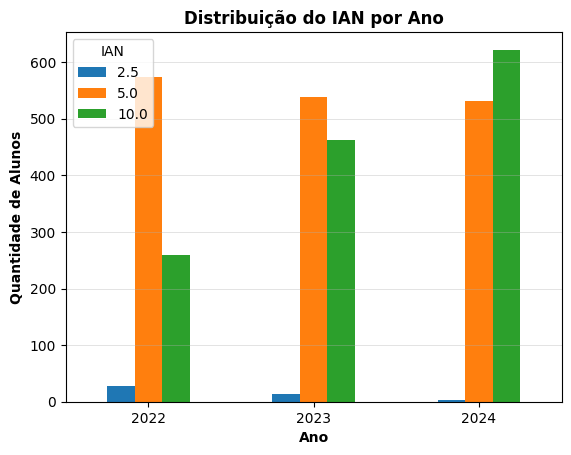

In [ ]:
df_ian = df.groupby(['ano','ian']).size().unstack()

df_ian.plot(kind="bar")
plt.title("Distribuição do IAN por Ano", weight="bold")
plt.ylabel("Quantidade de Alunos", weight="bold")
plt.xlabel("Ano", weight="bold")
plt.xticks(rotation=0)
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.legend(title="IAN")
plt.show()

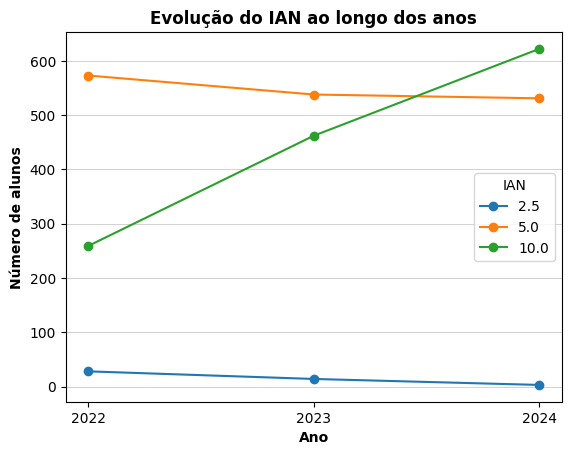

In [ ]:
df_ian.plot(marker="o")
plt.title("Evolução do IAN ao longo dos anos", weight="bold")
plt.xlabel("Ano", weight="bold")
plt.ylabel("Número de alunos", weight="bold")
plt.xticks(df_ian.index)
plt.grid(True, axis="y", linewidth=0.5, alpha=0.8)
plt.legend(title="IAN")
plt.show()

## Pergunta 2 — Desempenho acadêmico (IDA)

Nesta seção, investigamos a evolução do desempenho acadêmico dos alunos por meio do indicador IDA.

A análise busca responder se o desempenho médio:
- está melhorando,
- permanecendo estável,
- ou caindo ao longo dos anos e das fases do programa.

Também consideramos as limitações estruturais dos dados em fases mais avançadas, nas quais há maior presença de valores ausentes.

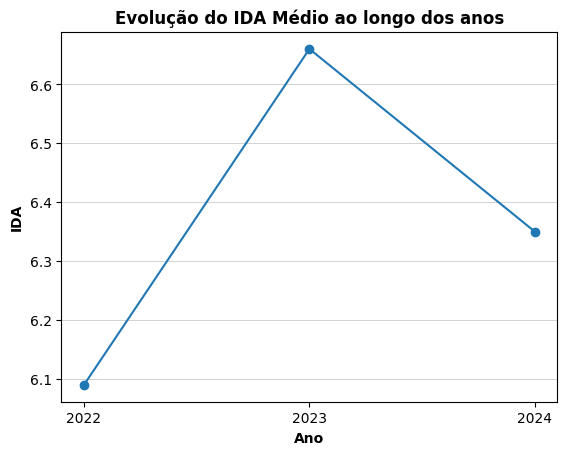

In [ ]:
df_ida = df.groupby("ano")["ida"].mean().round(2)
df_ida.plot(marker="o")
plt.title("Evolução do IDA Médio ao longo dos anos", weight="bold")
plt.xlabel("Ano", weight="bold")
plt.ylabel("IDA", weight="bold")
plt.xticks(df_ida.index)
plt.grid(True, axis="y", linewidth=0.5, alpha=0.8)
plt.show()

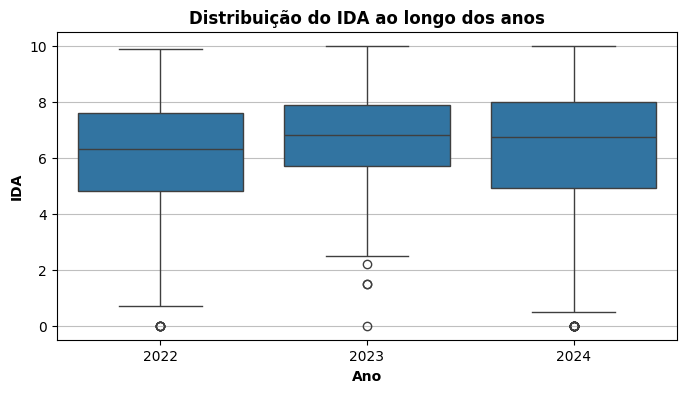

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="ano", y="ida")
plt.title("Distribuição do IDA ao longo dos anos", weight='bold')
plt.xlabel("Ano", weight='bold')
plt.ylabel("IDA", weight='bold')
plt.grid(True, axis="y", alpha=0.8)
plt.show()

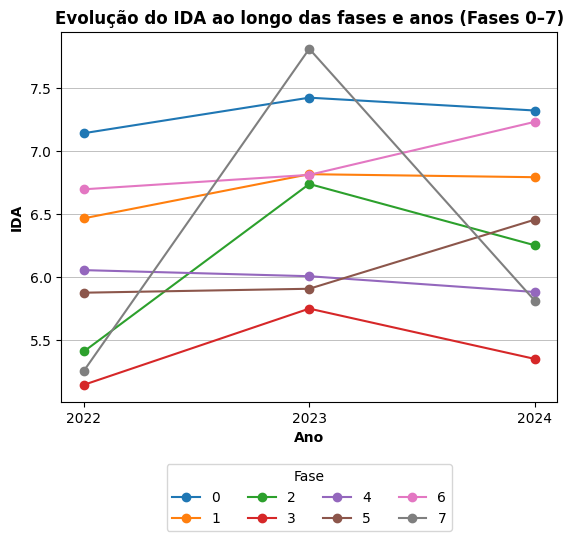

In [ ]:
df_filtrado = df[~df["Fase"].isin([8, 9])]  # A fase 8 somente apresenta 1 instância com o valor de IDA e a fase 9 não apresenta nenhum valor

df_ida_fase = df_filtrado.groupby(["ano", "Fase"])["ida"].mean().unstack()
df_ida_fase.plot(marker="o")
plt.title("Evolução do IDA ao longo das fases e anos (Fases 0–7)", weight='bold')
plt.xlabel("Ano", weight='bold')
plt.ylabel("IDA", weight='bold')
plt.xticks(df_ida_fase.index)
plt.grid(True, axis="y", linewidth=0.7, alpha=0.8)
plt.legend(
    title="Fase",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4
)
plt.show()

In [ ]:
df_filtrado.groupby(["ano", "Fase"])["ida"].mean().round(2).unstack()

Fase,0,1,2,3,4,5,6,7
ano,,,,,,,,
2022,7.14,6.46,5.41,5.14,6.05,5.87,6.69,5.25
2023,7.42,6.81,6.74,5.75,6.00,5.90,6.81,7.81
2024,7.32,6.79,6.25,5.35,5.88,6.45,7.23,5.81


## Pergunta 3 — Engajamento nas atividades (IEG)
Nesta seção, analisamos se o grau de engajamento dos alunos está associado ao desempenho acadêmico (IDA) e ao ponto de virada (IPV) no mesmo período.

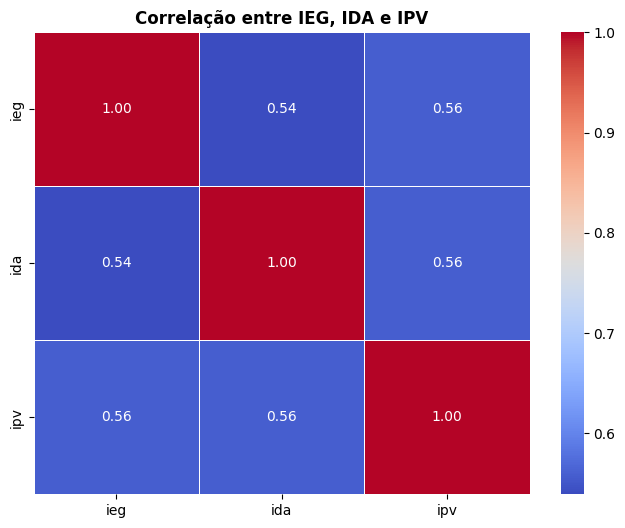

In [ ]:
corr_ieg = df[["ieg", "ida", "ipv"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_ieg,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlação entre IEG, IDA e IPV", weight="bold")
plt.show()

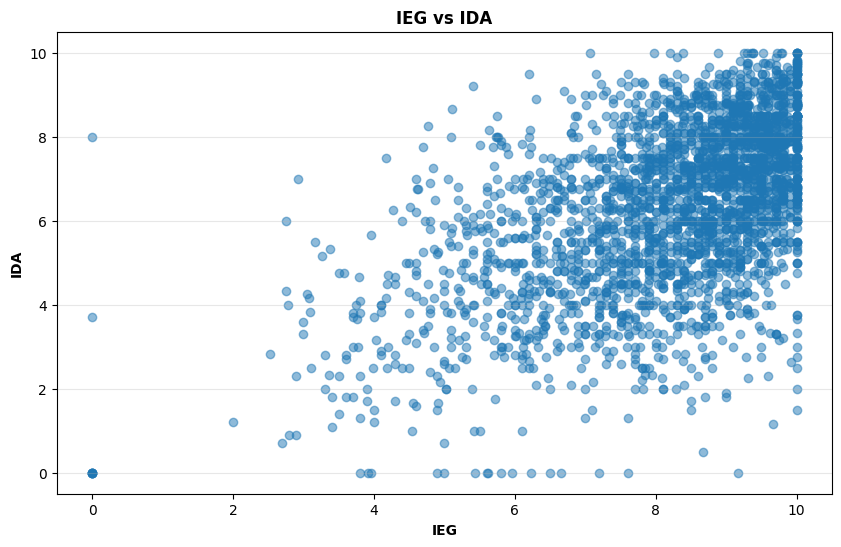

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df["ieg"], df["ida"], alpha=0.5)
plt.title("IEG vs IDA", weight="bold")
plt.xlabel("IEG", weight="bold")
plt.ylabel("IDA", weight="bold")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [ ]:
df['faixa_ieg'] = pd.qcut(df['ieg'], 3, labels=['Baixo','Médio','Alto'])

media_por_faixa = df.groupby('faixa_ieg')['ida'].mean()
mediaIPV_por_faixa = df.groupby('faixa_ieg')['ipv'].mean()

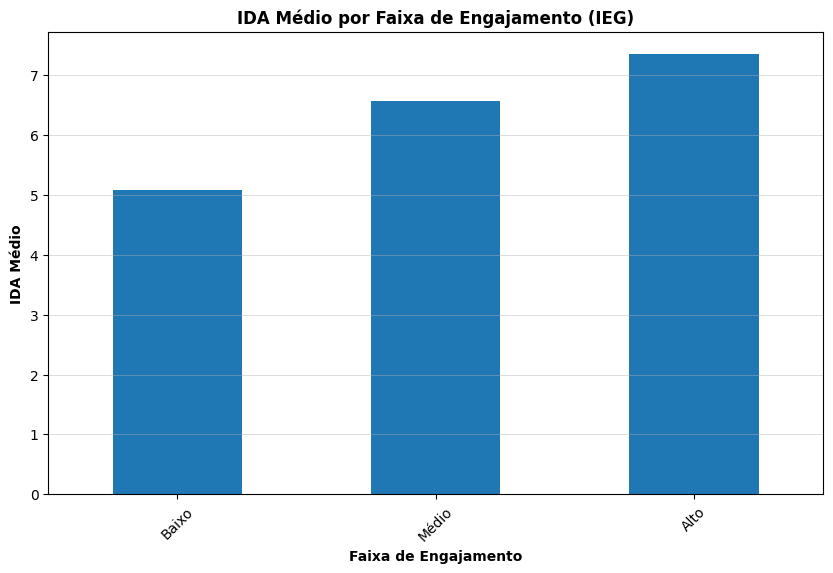

In [ ]:
plt.figure(figsize=(10,6))
media_por_faixa.plot(kind="bar")
plt.title("IDA Médio por Faixa de Engajamento (IEG)", weight="bold")
plt.xlabel("Faixa de Engajamento", weight="bold")
plt.ylabel("IDA Médio", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.6)
plt.xticks(rotation=45)
plt.show()

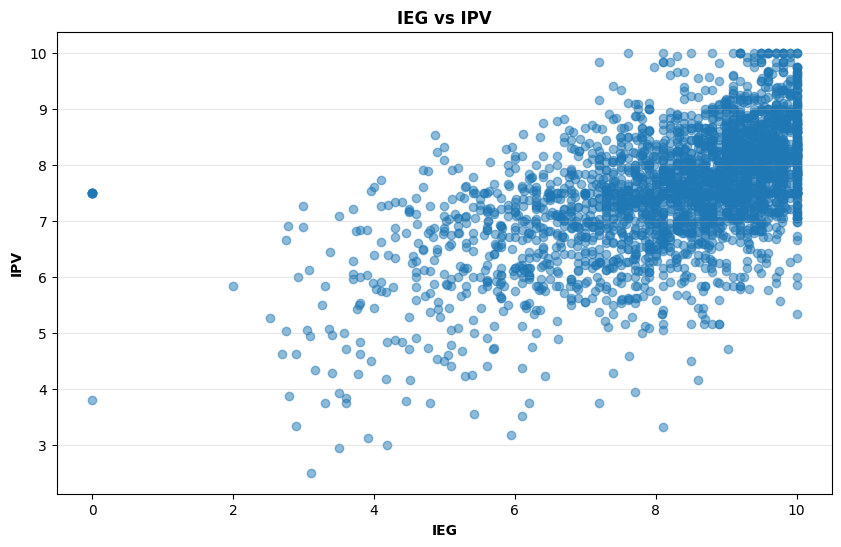

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df["ieg"], df["ipv"], alpha=0.5)
plt.title("IEG vs IPV", weight="bold")
plt.xlabel("IEG", weight="bold")
plt.ylabel("IPV", weight="bold")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

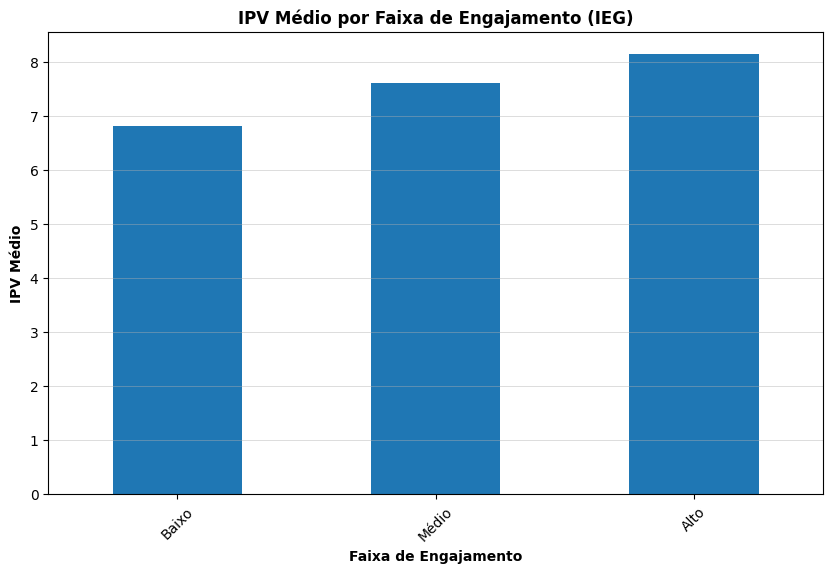

In [ ]:
plt.figure(figsize=(10,6))
mediaIPV_por_faixa.plot(kind="bar")
plt.title("IPV Médio por Faixa de Engajamento (IEG)", weight="bold")
plt.xlabel("Faixa de Engajamento", weight="bold")
plt.ylabel("IPV Médio", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.6)
plt.xticks(rotation=45)
plt.show()

## Pergunta 4 — Autoavaliação (IAA)

Nesta seção, analisamos se a percepção que os alunos têm sobre si mesmos, representada pelo indicador IAA, é coerente com seu desempenho acadêmico (IDA) e com seu engajamento nas atividades (IEG).

O objetivo é verificar se alunos que se autoavaliam melhor também tendem a apresentar melhores resultados acadêmicos e maior engajamento, identificando possíveis alinhamentos ou discrepâncias entre percepção e desempenho real.

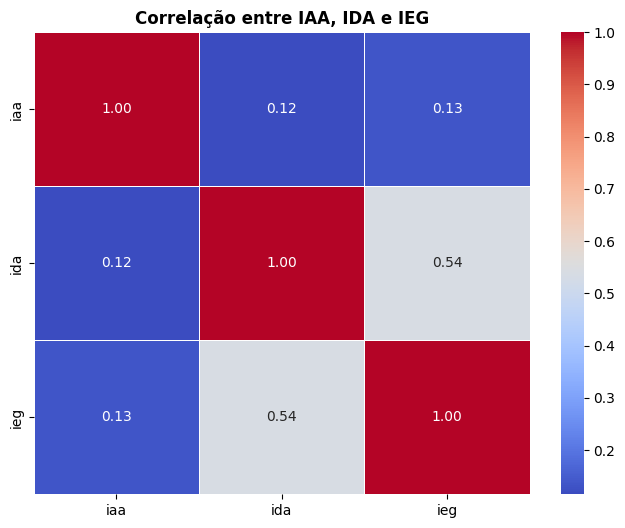

In [ ]:
corr_iaa = df[["iaa", "ida", "ieg"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_iaa, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlação entre IAA, IDA e IEG", weight="bold")
plt.show()

In [ ]:
df["iaa_clean"] = df["iaa"].replace(0.0, np.nan)   # Muitos valores de iaa como 0,0 sugerindo missing codificado

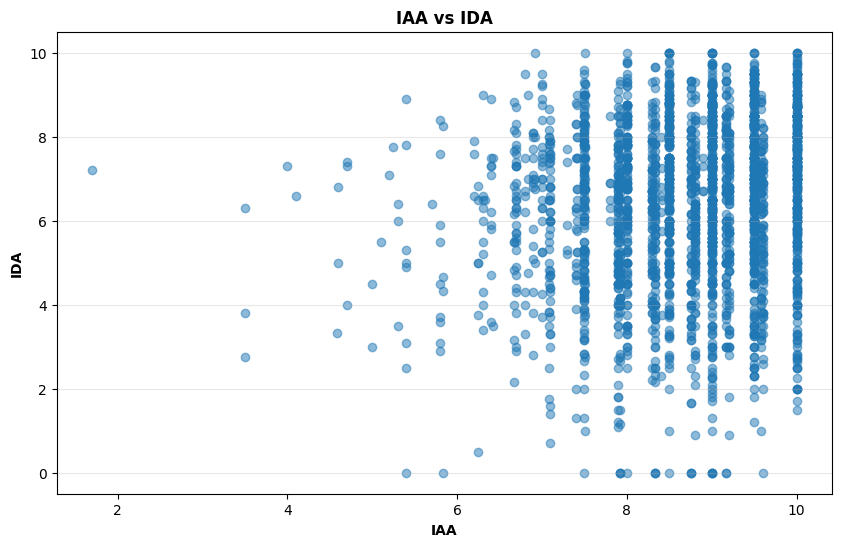

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df["iaa_clean"], df["ida"], alpha=0.5)
plt.title("IAA vs IDA", weight="bold")
plt.xlabel("IAA", weight="bold")
plt.ylabel("IDA", weight="bold")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [ ]:
df["faixa_iaa"] = pd.qcut(df["iaa_clean"], 3, labels=["Baixo","Médio","Alto"])

media_ida_iaa = df.groupby("faixa_iaa")["ida"].mean()
media_ieg_iaa = df.groupby("faixa_iaa")["ieg"].mean()

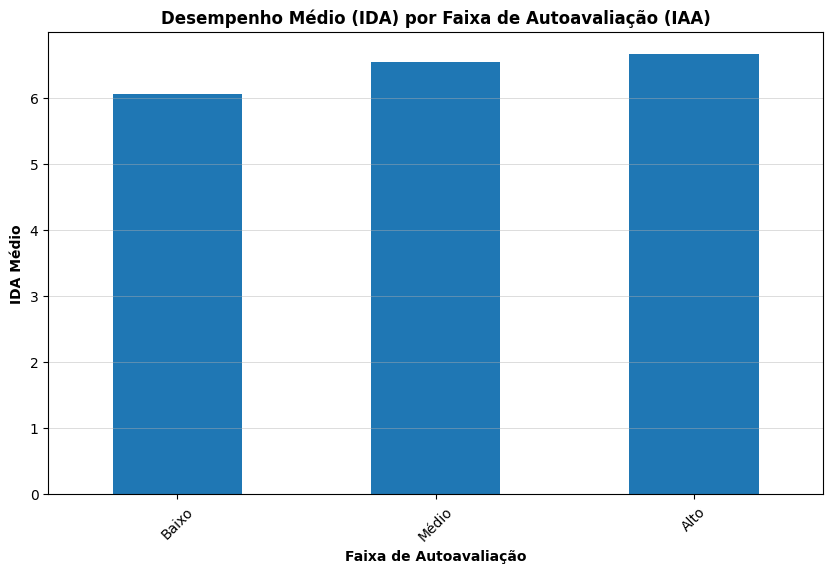

In [ ]:
plt.figure(figsize=(10,6))
media_ida_iaa.plot(kind="bar")
plt.title("Desempenho Médio (IDA) por Faixa de Autoavaliação (IAA)", weight="bold")
plt.xlabel("Faixa de Autoavaliação", weight="bold")
plt.ylabel("IDA Médio", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.6)
plt.xticks(rotation=45)
plt.show()

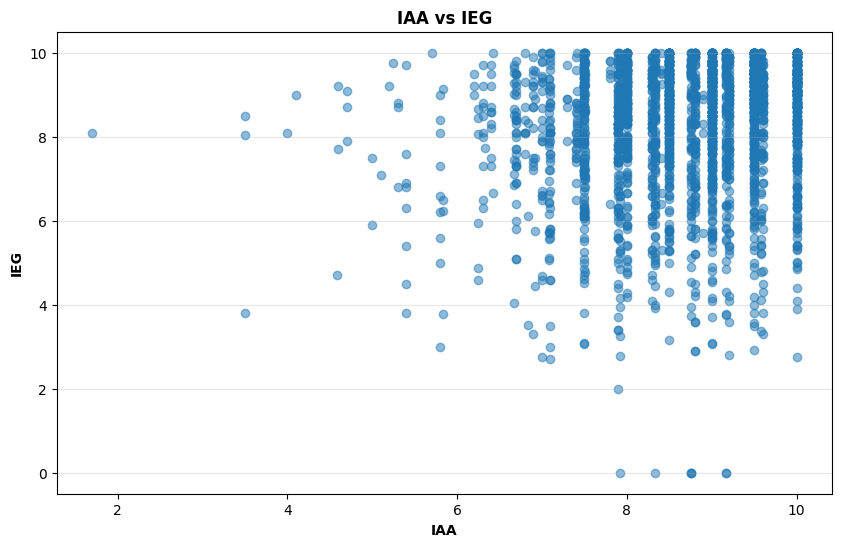

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df["iaa_clean"], df["ieg"], alpha=0.5)
plt.title("IAA vs IEG", weight="bold")
plt.xlabel("IAA", weight="bold")
plt.ylabel("IEG", weight="bold")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

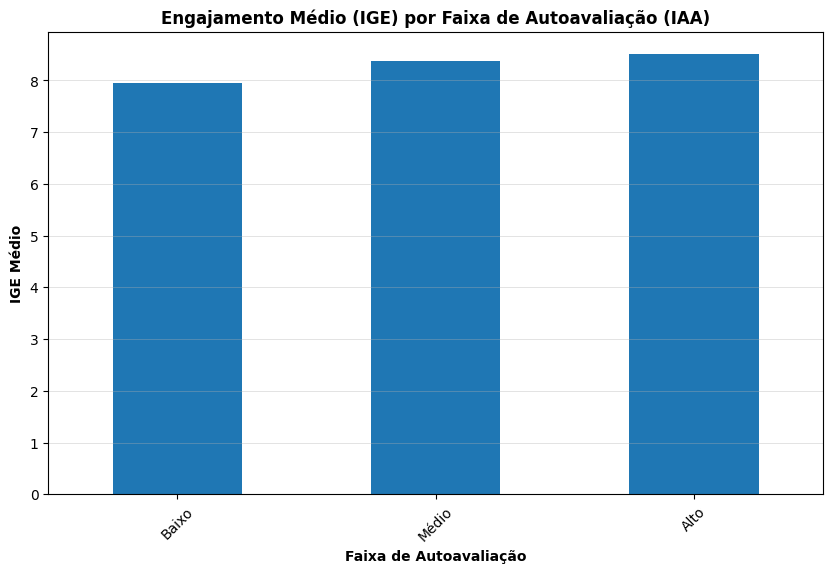

In [ ]:
plt.figure(figsize=(10,6))
media_ieg_iaa.plot(kind="bar")
plt.title("Engajamento Médio (IGE) por Faixa de Autoavaliação (IAA)", weight="bold")
plt.xlabel("Faixa de Autoavaliação", weight="bold")
plt.ylabel("IGE Médio", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.xticks(rotation=45)
plt.show()

## Pergunta 5 — Aspectos psicossociais (IPS)

Nesta seção, investigamos se o indicador psicossocial (IPS) apresenta relação com o desempenho acadêmico e o engajamento dos alunos, especialmente em uma perspectiva temporal.

O objetivo é verificar se padrões psicossociais podem anteceder quedas no desempenho acadêmico (IDA) e no engajamento (IEG), identificando sinais prévios de risco que possam apoiar intervenções mais precoces.

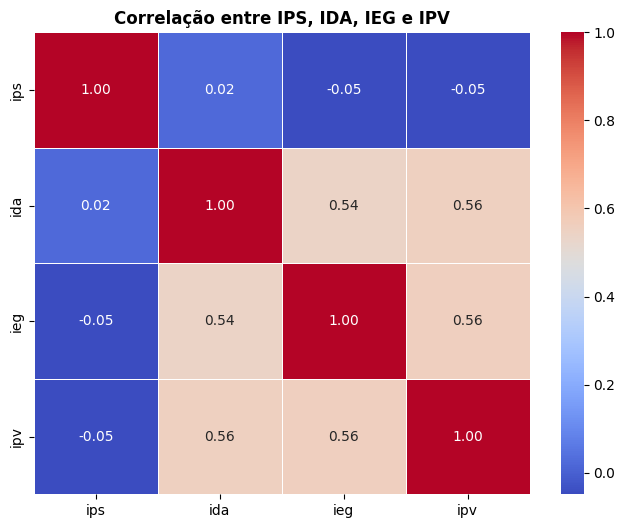

In [ ]:
corr_ips = df[["ips", "ida", "ieg", "ipv"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_ips, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlação entre IPS, IDA, IEG e IPV", weight="bold")
plt.show()

In [ ]:
df_ida = df.copy()

df_ida["ida_futuro"] = df_ida.groupby("RA")["ida"].shift(-1)
df_ida = df_ida.dropna(subset=["ida_futuro"])

df_ida["faixa_ips"] = pd.qcut(df_ida["ips"], 3, labels=["Baixo","Médio","Alto"])

In [ ]:
df_ieg = df.copy()

df_ieg["ieg_futuro"] = df_ieg.groupby("RA")["ieg"].shift(-1)
df_ieg = df_ieg.dropna(subset=["ieg_futuro"])

df_ieg["faixa_ips"] = pd.qcut(df_ieg["ips"], 3, labels=["Baixo","Médio","Alto"])

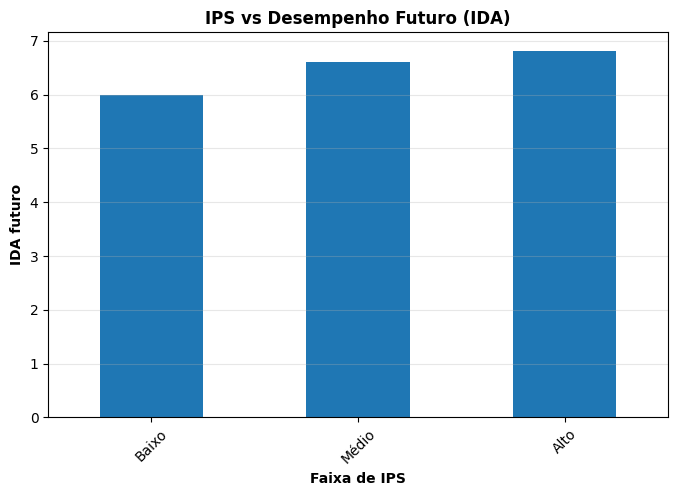

In [ ]:
df_ida.groupby("faixa_ips")["ida_futuro"].mean().plot(
    kind="bar", figsize=(8,5))
plt.title("IPS vs Desempenho Futuro (IDA)", weight="bold")
plt.ylabel("IDA futuro", weight="bold")
plt.xlabel("Faixa de IPS", weight="bold")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.show()

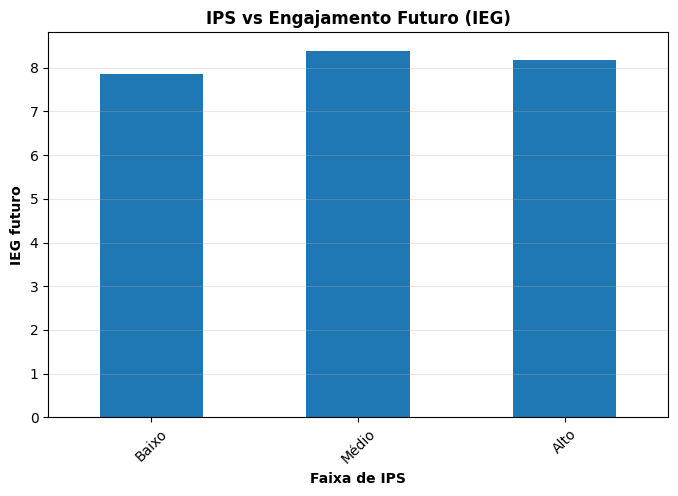

In [ ]:
df_ieg.groupby("faixa_ips")["ieg_futuro"].mean().plot(
    kind="bar", figsize=(8,5))
plt.title("IPS vs Engajamento Futuro (IEG)", weight="bold")
plt.ylabel("IEG futuro", weight="bold")
plt.xlabel("Faixa de IPS", weight="bold")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.show()

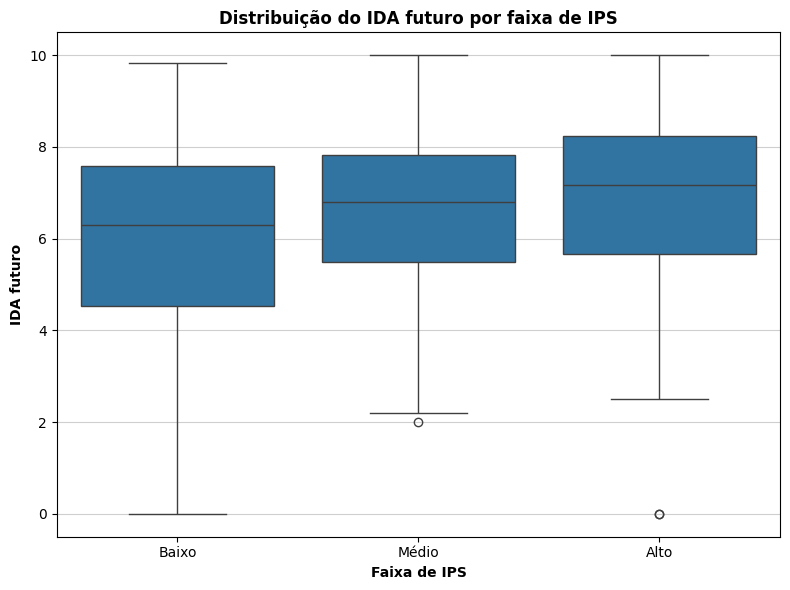

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_ida, x="faixa_ips", y="ida_futuro")
plt.title("Distribuição do IDA futuro por faixa de IPS", weight="bold")
plt.xlabel("Faixa de IPS", weight="bold")
plt.ylabel("IDA futuro", weight="bold")
plt.grid(True, axis="y", alpha=0.6)
plt.tight_layout()
plt.show()

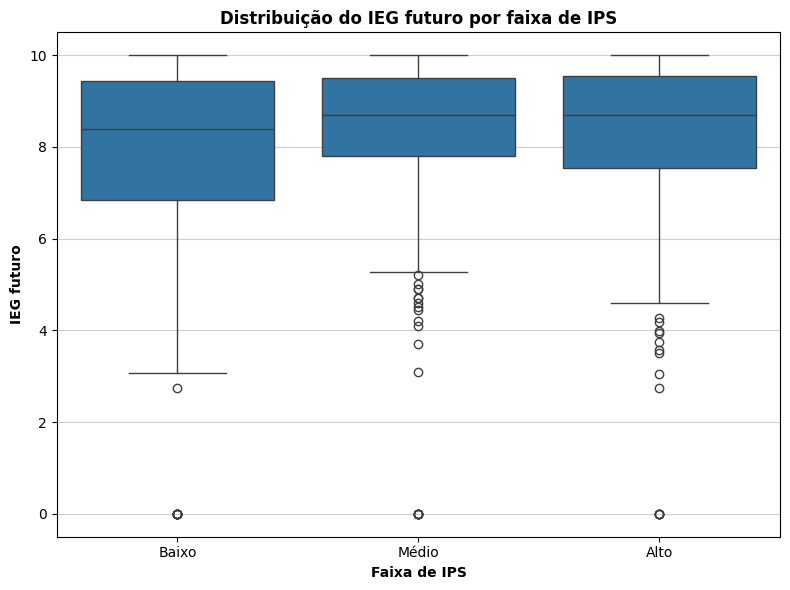

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_ieg, x="faixa_ips", y="ieg_futuro")
plt.title("Distribuição do IEG futuro por faixa de IPS", weight="bold")
plt.xlabel("Faixa de IPS", weight="bold")
plt.ylabel("IEG futuro", weight="bold")
plt.grid(True, axis="y", alpha=0.6)
plt.tight_layout()
plt.show()

## Pergunta 6 — Aspectos psicopedagógicos (IPP)

Nesta seção, analisamos a relação entre o indicador psicopedagógico (IPP) e o nível de defasagem dos alunos, representado pelo IAN.

O objetivo é verificar se o IPP confirma ou contradiz a defasagem identificada, avaliando se alunos em situações mais críticas também apresentam resultados psicopedagógicos inferiores.

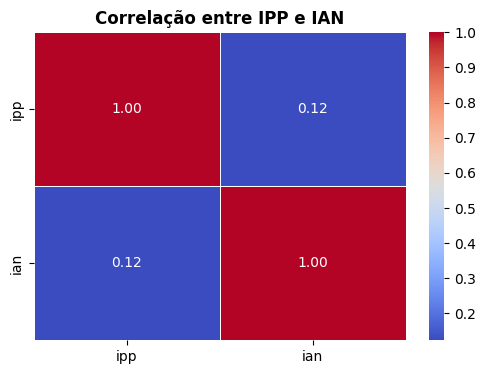

In [ ]:
corr_ipp = df[["ipp", "ian"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_ipp, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlação entre IPP e IAN", weight="bold")
plt.show()

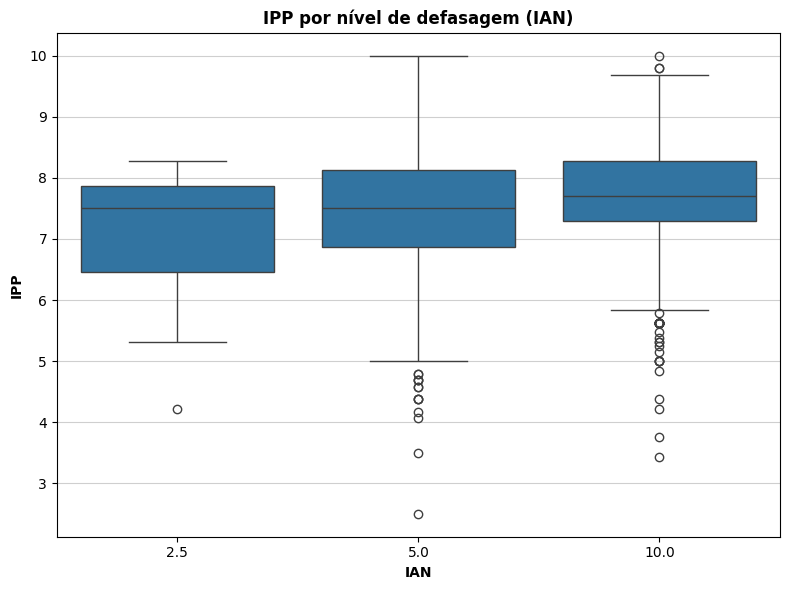

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x="ian", y="ipp", data=df)
plt.title("IPP por nível de defasagem (IAN)", weight="bold")
plt.xlabel("IAN", weight="bold")
plt.ylabel("IPP", weight="bold")
plt.grid(True, axis="y", alpha=0.6)
plt.tight_layout()
plt.show()

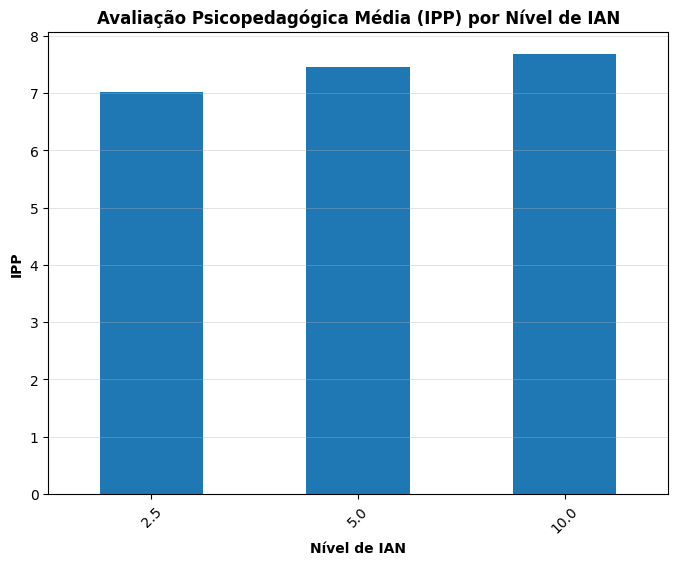

In [ ]:
media_ipp_ian = df.groupby('ian')['ipp'].mean()
plt.figure(figsize=(8,6))
media_ipp_ian.plot(kind="bar")
plt.title("Avaliação Psicopedagógica Média (IPP) por Nível de IAN", weight="bold")
plt.xlabel("Nível de IAN", weight="bold")
plt.ylabel("IPP", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.xticks(rotation=45)
plt.show()

## Pergunta 7 — Ponto de virada (IPV)

Nesta seção, investigamos quais fatores estão mais associados ao ponto de virada dos alunos, representado pelo indicador IPV.

O objetivo é identificar quais dimensões — acadêmicas, emocionais ou de engajamento — parecem influenciar mais esse indicador, contribuindo para compreender melhor os fatores relacionados à evolução dos alunos no programa.

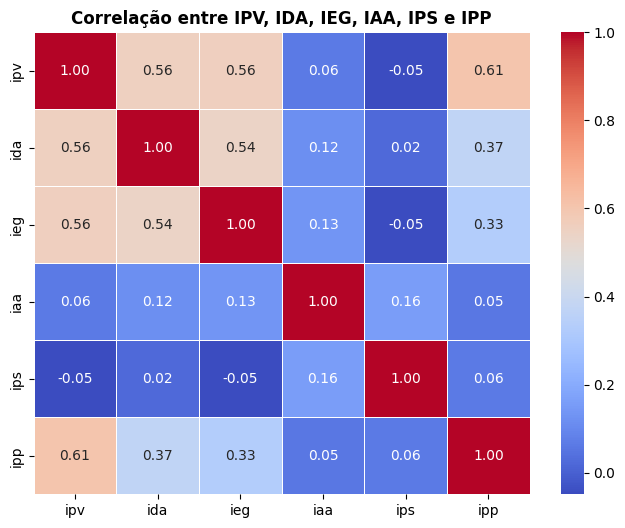

In [ ]:
corr_ipv = df[['ipv','ida','ieg','iaa','ips','ipp']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_ipv, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlação entre IPV, IDA, IEG, IAA, IPS e IPP", weight="bold")
plt.show()

In [ ]:
df['faixa_ida'] = pd.qcut(df['ida'], 3, labels=['Baixo','Médio','Alto'])

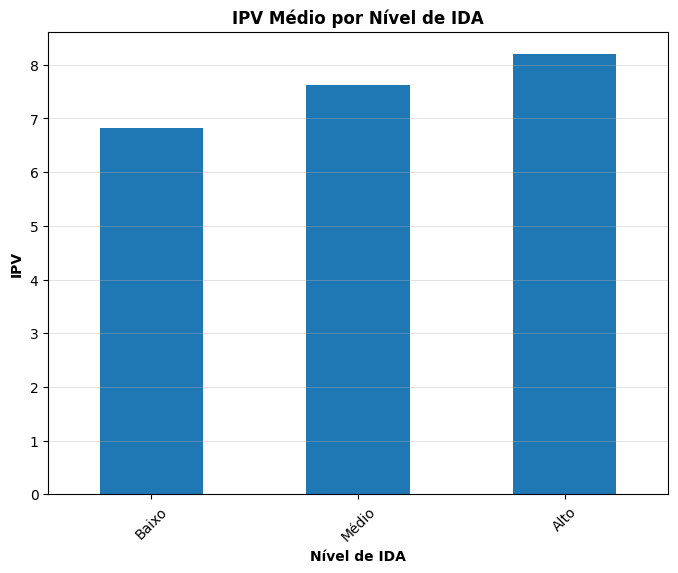

In [ ]:
media_ipv_ida = df.groupby('faixa_ida')['ipv'].mean()
plt.figure(figsize=(8,6))
media_ipv_ida.plot(kind="bar")
plt.title("IPV Médio por Nível de IDA", weight="bold")
plt.xlabel("Nível de IDA", weight="bold")
plt.ylabel("IPV", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['faixa_ieg'] = pd.qcut(df['ieg'], 3, labels=['Baixo','Médio','Alto'])

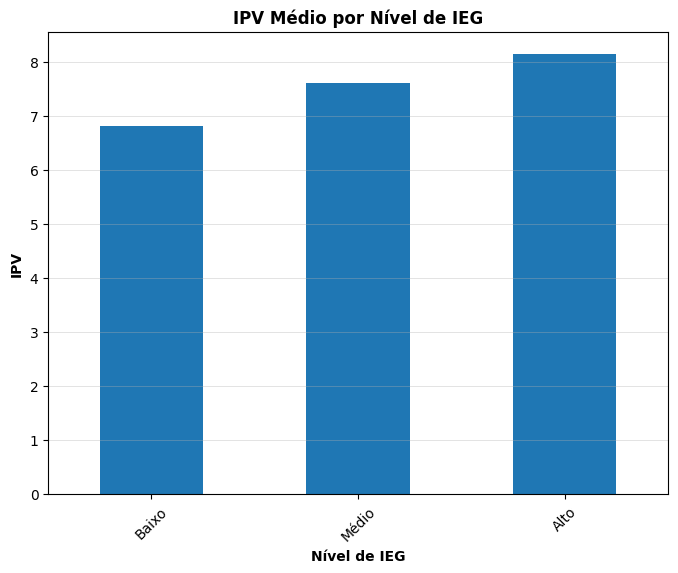

In [ ]:
media_ipv_ieg = df.groupby('faixa_ieg')['ipv'].mean()
plt.figure(figsize=(8,6))
media_ipv_ieg.plot(kind="bar")
plt.title("IPV Médio por Nível de IEG", weight="bold")
plt.xlabel("Nível de IEG", weight="bold")
plt.ylabel("IPV", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['faixa_ipp'] = pd.qcut(df['ipp'], 3, labels=['Baixo','Médio','Alto'])

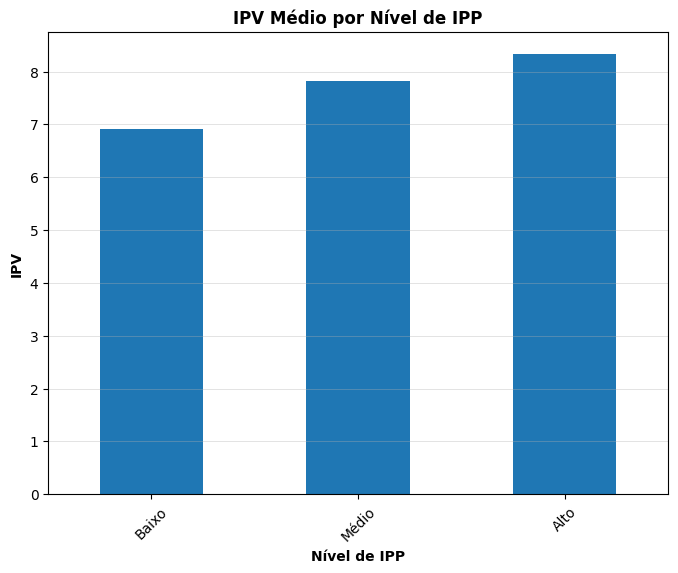

In [ ]:
media_ipv_ipp = df.groupby('faixa_ipp')['ipv'].mean()
plt.figure(figsize=(8,6))
media_ipv_ipp.plot(kind="bar")
plt.title("IPV Médio por Nível de IPP", weight="bold")
plt.xlabel("Nível de IPP", weight="bold")
plt.ylabel("IPV", weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.xticks(rotation=45)
plt.show()

## Pergunta 8 — Multidimensionalidade dos indicadores

Nesta seção, analisamos como diferentes combinações de indicadores se relacionam com a nota global do aluno, representada pelo INDE.

O objetivo é identificar quais fatores individuais e combinados — especialmente IDA, IEG, IPS e IPP — estão mais associados a níveis mais altos de desempenho global, permitindo compreender melhor os principais direcionadores do INDE.

In [ ]:
cols = ["inde", "ida", "ieg", "ips", "ipp", "iaa", "ipv"]
df_corr = df[cols].dropna()
df_corr.corr()["inde"].sort_values(ascending=False)

,inde
inde,1.000000
ida,0.766744
ieg,0.708827
ipv,0.677325
ipp,0.540295
iaa,0.411724
ips,0.247743


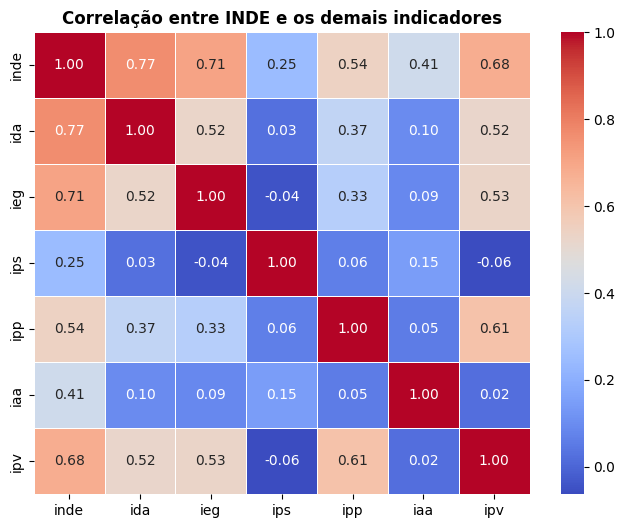

In [ ]:
corr_inde = df_corr.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_inde, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlação entre INDE e os demais indicadores", weight="bold")
plt.show()

In [ ]:
df['faixa_ipv'] = pd.qcut(df['ipv'], 3, labels=['Baixo','Médio','Alto'])

In [ ]:
df2 = df.groupby(["faixa_ida","faixa_ieg", "faixa_ipv", "faixa_ipp"])["inde"].mean().sort_values(ascending=False)

In [ ]:
df2.head(10)

faixa_ida  faixa_ieg  faixa_ipv  faixa_ipp
Alto       Alto       Alto       Alto         8.544097
                                 Médio        8.410250
                      Médio      Alto         8.283566
                      Baixo      Alto         8.207433
                      Médio      Médio        8.193938
           Médio      Alto       Alto         8.175189
           Alto       Alto       Baixo        8.109194
Médio      Alto       Alto       Alto         8.009101
Alto       Médio      Alto       Médio        7.999964
           Baixo      Alto       Alto         7.982782
Name: inde, dtype: float64

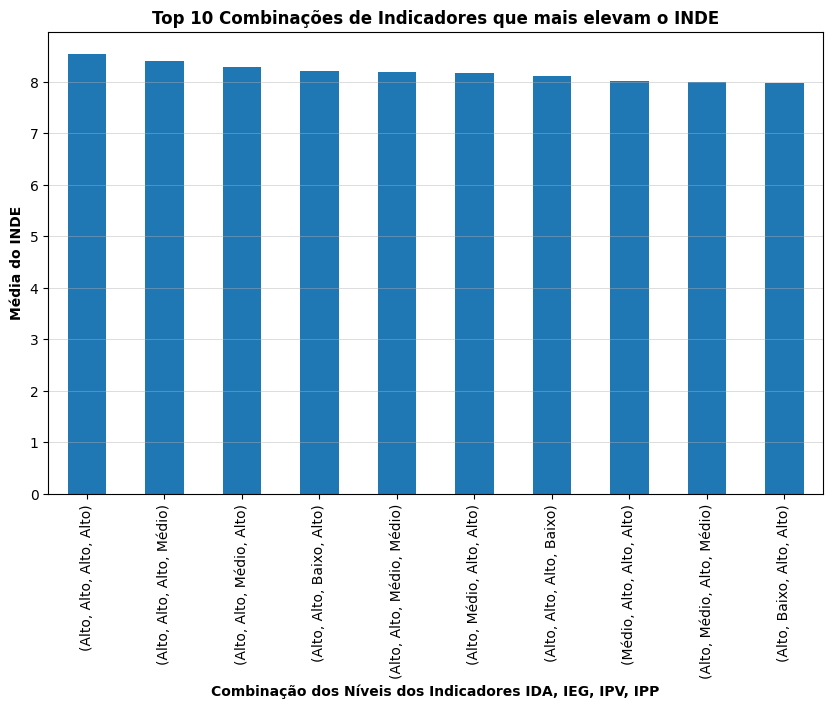

In [ ]:
plt.figure(figsize=(10,6))
df2.head(10).plot(kind='bar')
plt.title('Top 10 Combinações de Indicadores que mais elevam o INDE', weight="bold")
plt.xlabel('Combinação dos Níveis dos Indicadores IDA, IEG, IPV, IPP', weight="bold")
plt.ylabel('Média do INDE', weight="bold")
plt.grid(True, axis="y", linewidth=0.5, alpha=0.6)
plt.show()

## Pergunta 9 — Padrões de risco para modelagem preditiva
Nesta seção, exploramos padrões que podem auxiliar na identificação de alunos em risco de defasagem, servindo como base para a etapa de modelagem preditiva.

Diferentemente das análises anteriores, que focam na relação entre indicadores no mesmo período, aqui adotamos uma abordagem temporal, investigando se os valores observados em um determinado ano podem anteceder situações de defasagem ou alterações no desempenho em períodos futuros.

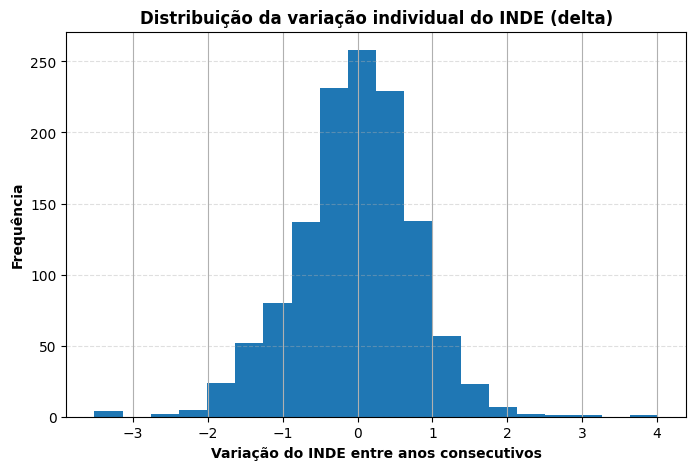

In [ ]:
df_variacao_inde = df.copy()
df_variacao_inde["delta_inde"] = df_variacao_inde.groupby("RA")["inde"].diff()

plt.figure(figsize=(8,5))
df_variacao_inde["delta_inde"].hist(bins=20)
plt.title("Distribuição da variação individual do INDE (delta)", weight="bold")
plt.xlabel("Variação do INDE entre anos consecutivos", weight="bold")
plt.ylabel("Frequência", weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [ ]:
df3 = df_variacao_inde.copy()
cols_prev = ["ida", "ieg", "ipv", "ips", "ipp", "ian", "defasagem"]

for col in cols_prev:
    df3[f"{col}_prev"] = df3.groupby("RA")[col].shift(1)

In [ ]:
df_defasagem_vigente = df3[df3["defasagem"] < 0].copy()

In [ ]:
df_defasagem_vigente.dropna(inplace=True)

In [ ]:
df_defasagem_vigente[
    ["RA", "ano", "defasagem", "ida_prev", "ieg_prev", "ipv_prev", "ips_prev", "ipp_prev", "ian_prev"]
].head(20)

,RA,ano,defasagem,ida_prev,ieg_prev,ipv_prev,ips_prev,ipp_prev,ian_prev
88,RA-42,2024,-1,5.7,8.6,6.6675,5.63,6.56250,5.0
172,RA-85,2024,-2,5.7,8.9,7.8425,6.27,5.93750,5.0
189,RA-91,2024,-1,7.4,7.4,7.4675,6.89,7.81250,5.0
223,RA-107,2024,-1,7.0,8.5,7.5875,5.00,7.34375,10.0
243,RA-115,2024,-2,4.2,7.1,7.2150,5.00,7.34375,5.0
246,RA-116,2024,-2,4.7,7.6,7.5475,5.00,7.96875,5.0
255,RA-121,2024,-2,6.0,8.8,7.4625,5.00,7.34375,5.0
259,RA-123,2024,-1,5.7,9.4,6.8375,5.00,6.87500,5.0
263,RA-125,2024,-1,5.8,7.7,7.8350,5.00,8.12500,5.0
274,RA-131,2024,-2,2.2,7.8,6.8000,5.00,7.65625,5.0


In [ ]:
df_defasagem_vigente[["ida_prev", "ieg_prev", "ipv_prev", "ips_prev", "ipp_prev", "ian_prev"]].mean()

,0
ida_prev,5.591176
ieg_prev,8.339216
ipv_prev,7.514060
ips_prev,4.705294
ipp_prev,7.491319
ian_prev,5.490196


In [ ]:
df3["defasado_atual"] = (df3["defasagem"] < 0).astype(int)

In [ ]:
df3.groupby("defasado_atual")[
    ["ida_prev", "ieg_prev", "ipv_prev", "ips_prev", "ipp_prev"]
].mean()

,ida_prev,ieg_prev,ipv_prev,ips_prev,ipp_prev
defasado_atual,,,,,
0,7.027010,8.871222,8.157681,5.657906,8.009226
1,6.309926,8.337926,7.477469,6.249583,7.123241


In [ ]:
df_risco = df[
    (df["ida"] < 6) &
    (df["ipv"] < 7) &
    (df["ipp"] < 7)
]

len(df_risco)

167

## Pergunta 10 — Efetividade do programa

Nesta seção, avaliamos se os indicadores mostram melhora consistente ao longo do ciclo do programa, considerando as fases Quartzo, Ágata, Ametista e Topázio.

O objetivo é verificar se há evidências de progressão dos alunos ao longo das fases, tanto em termos do indicador global (INDE) quanto de outros indicadores relevantes, como desempenho acadêmico (IDA) e engajamento (IEG).

In [ ]:
ordem = ["Quartzo", "Ágata", "Ametista", "Topázio"]
df.groupby("pedra")["inde"].mean().round(2).reindex(ordem)

,inde
pedra,
Quartzo,5.37
Ágata,6.59
Ametista,7.52
Topázio,8.44


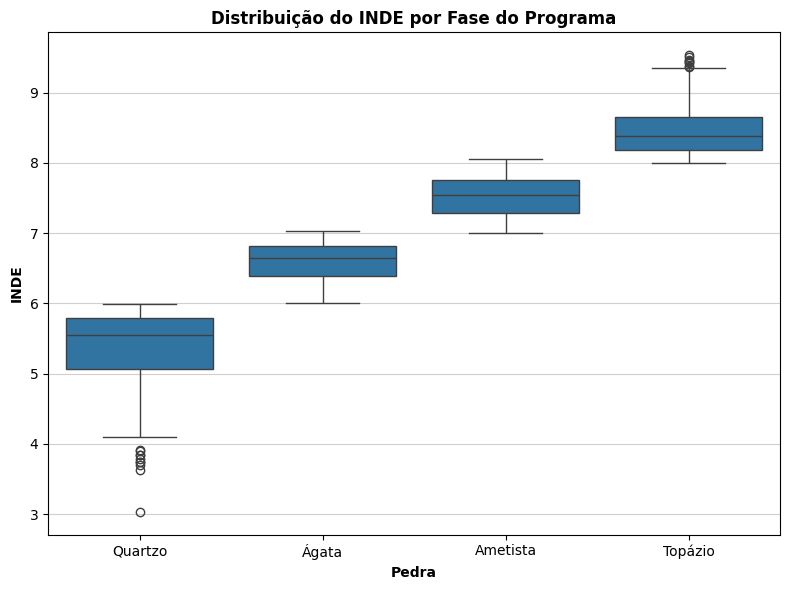

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x="pedra", y="inde", data=df, order=ordem)
plt.title("Distribuição do INDE por Fase do Programa", weight="bold")
plt.xlabel("Pedra", weight="bold")
plt.ylabel("INDE", weight="bold")
plt.grid(True, axis="y", alpha=0.6)
plt.tight_layout()
plt.show()

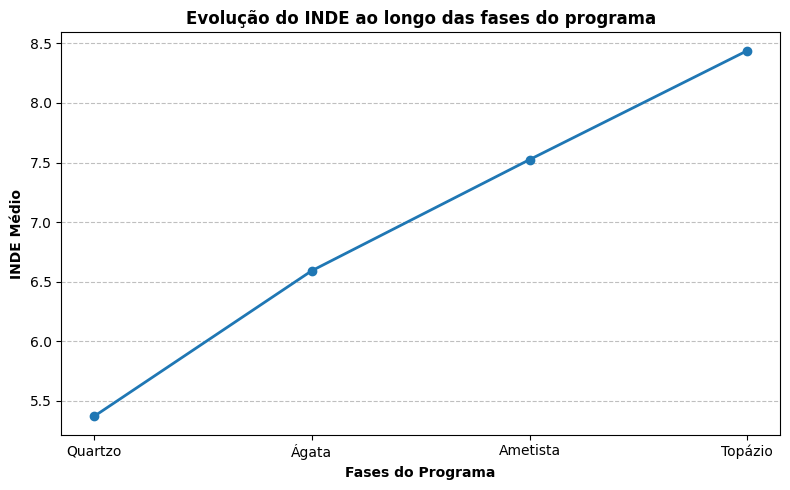

In [ ]:
df_pedra = df.groupby("pedra")["inde"].mean().reindex(ordem)

plt.figure(figsize=(8,5))
plt.plot(df_pedra.index, df_pedra.values, marker="o", linewidth=2)
plt.title("Evolução do INDE ao longo das fases do programa", weight="bold")
plt.xlabel("Fases do Programa", weight="bold" )
plt.ylabel("INDE Médio", weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.8)
plt.tight_layout()
plt.show()

In [ ]:
df.groupby("pedra")["inde"].mean().reindex(ordem)

,inde
pedra,
Quartzo,5.368562
Ágata,6.591564
Ametista,7.524473
Topázio,8.439701


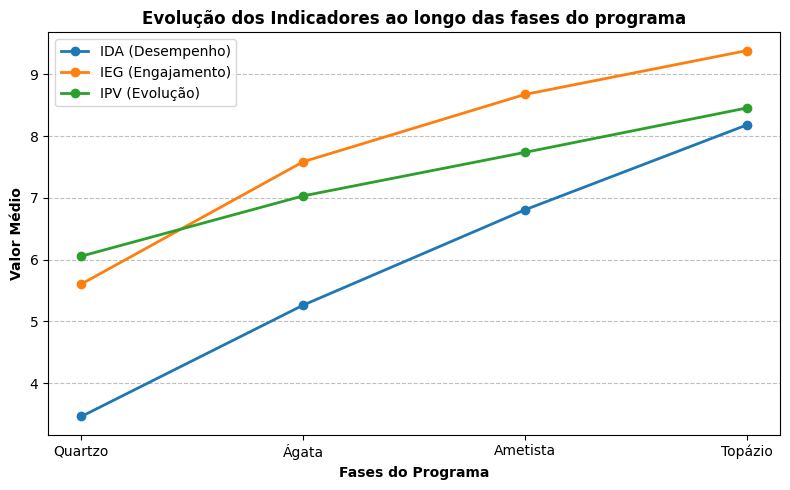

In [ ]:
df_mult = (df.groupby("pedra")[["ida", "ieg", "ipv"]].mean().reindex(ordem))

plt.figure(figsize=(8,5))
plt.plot(df_mult.index, df_mult["ida"], marker="o", linewidth=2, label="IDA (Desempenho)")
plt.plot(df_mult.index, df_mult["ieg"], marker="o", linewidth=2, label="IEG (Engajamento)")
plt.plot(df_mult.index, df_mult["ipv"], marker="o", linewidth=2, label="IPV (Evolução)")
plt.title("Evolução dos Indicadores ao longo das fases do programa", weight="bold")
plt.xlabel("Fases do Programa", weight="bold")
plt.ylabel("Valor Médio", weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.8)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df.groupby("pedra")[["ida","ieg","ips","ipp","ipv"]].mean()

,ida,ieg,ips,ipp,ipv
pedra,,,,,
Ametista,6.807292,8.675153,6.305415,7.603553,7.737460
Quartzo,3.461973,5.606515,5.790585,6.551744,6.057199
Topázio,8.180766,9.384573,6.836937,8.134091,8.455660
Ágata,5.264124,7.585811,5.993662,7.185399,7.032720


## Pergunta 11 - Demais insights e pontos de vista

In [ ]:
df.groupby("Fase")["defasagem"].mean()

,defasagem
Fase,
0,-0.829822
1,-0.905455
2,-0.616667
3,-0.505092
4,-0.670175
5,-0.768889
6,-0.763158
7,0.308642
8,0.015748


In [ ]:
df.groupby(["ano","instituicao_ensino"])["inde"].mean()

ano   instituicao_ensino              
2022  Privada                             7.699806
      Pública                             6.940867
2023  Concluiu EM                         7.364835
      Outros                              7.368667
      Privada                             7.323877
      Privada com bolsa/apadrinhamento    7.534562
      Pública                             7.320425
2024  Concluiu EM                         7.269364
      Privada                             7.512550
      Privada com bolsa/apadrinhamento    8.098247
      Pública                             7.310685
Name: inde, dtype: float64

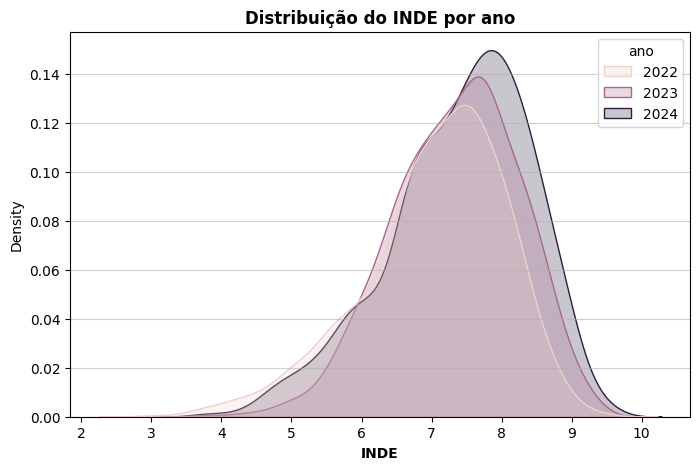

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="inde", hue="ano", fill=True)
plt.title("Distribuição do INDE por ano", weight="bold")
plt.xlabel("INDE", weight="bold")
plt.grid(True, axis="y", alpha=0.6)
plt.show()

In [ ]:
df.groupby("instituicao_ensino")["ian"].value_counts()

instituicao_ensino                ian 
Concluiu EM                       10.0      17
                                  5.0       10
Outros                            5.0        2
Privada                           10.0     138
                                  5.0       70
                                  2.5        4
Privada com bolsa/apadrinhamento  10.0     269
                                  5.0       45
Pública                           5.0     1515
                                  10.0     918
                                  2.5       41
Name: count, dtype: int64

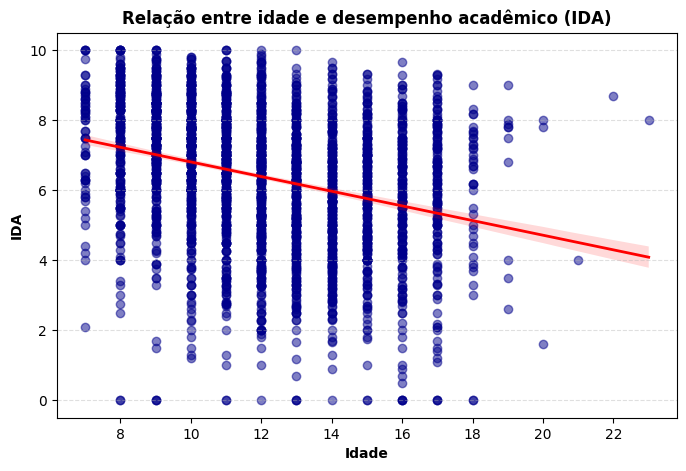

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(
    x="idade",
    y="ida",
    data=df,
    scatter_kws={"alpha":0.5, "color":"darkblue"},
    line_kws={"color":"red", "linewidth":2}
)

plt.title("Relação entre idade e desempenho acadêmico (IDA)", weight="bold")
plt.xlabel("Idade", weight="bold")
plt.ylabel("IDA", weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [ ]:
df.groupby("idade")["inde"].mean()

,inde
idade,
7,7.834559
8,7.818434
9,7.633095
10,7.490994
11,7.467276
12,7.077544
13,7.160244
14,6.966059
15,6.953341


In [ ]:
df["Fase"].value_counts().sort_index()

,count
Fase,
0,617
1,550
2,540
3,491
4,285
5,225
6,76
7,81
8,127


In [ ]:
df.groupby("ano")["defasagem"].value_counts()

ano   defasagem
2022  -1           410
       0           247
      -2           163
      -3            23
       1             9
      -4             4
       2             3
      -5             1
2023   0           420
      -1           408
      -2           130
       1            37
      -3            13
       2             5
      -4             1
2024   0           485
      -1           441
       1           119
      -2            90
       2            16
      -3             3
       3             2
Name: count, dtype: int64